# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## **Credit Risk Dataset**

Dataset ini merupakan data history peminjam yang digunakan untuk menganalisis risiko kredit dan memprediksi kemungkinan gagal bayar. Data ini tergolong ke dalam **Structured Data (Tabular)**.

- Sumber Dataset: https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data

- Karakteristik Fitur: Memiliki campuran data numerik (seperti usia, pendapatan, jumlah pinjaman, suku bunga) dan data kategorikal (seperti kepemilikan rumah, tujuan pinjaman, dan grade pinjaman).

- Variabel Target: loan_status (Kategorikal Biner).

  - 0 = Non-default (Peminjam berhasil melunasi)

  - 1 = Default (Peminjam gagal bayar)

- Target Analisis: Menentukan status pinjaman (`loan_status`) berdasarkan riwayat finansial dan demografi pelanggan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Ignore warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Load Dataset
df = pd.read_csv('../credit_risk_dataset.csv')

# Cek dimensi dan beberapa data awal
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Data Overview
- Dataset memiliki 12 kolom dan 32.581 baris.
- Kolom target: `loan_status` (0 = non-default, 1 = default).
- Terdapat kolom numerik dan kategorikal.

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Data Info dan Type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Check Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

,Missing,Percentage
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000


### Insight Missing Values:
- Kolom `person_emp_length` memiliki missing value sekitar 2.8% (895 baris).
- Kolom `loan_int_rate` memiliki missing value sekitar 9.5% (≈3000 baris).
- **Keputusan Preprocessing**: Missing value pada `person_emp_length` dapat diisi median, sedangkan `loan_int_rate` dapat diisi median berdasarkan `loan_grade`.

In [6]:
# Statistical Summary for Numerical Column
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Temuan Awal:
- `person_age` memiliki nilai max 144 tahun (outlier).
- `person_emp_length` memiliki max 123 tahun (outlier).
- `person_income` memiliki max 6 juta (outlier).
- Perlu dilakukan outlier treatment.

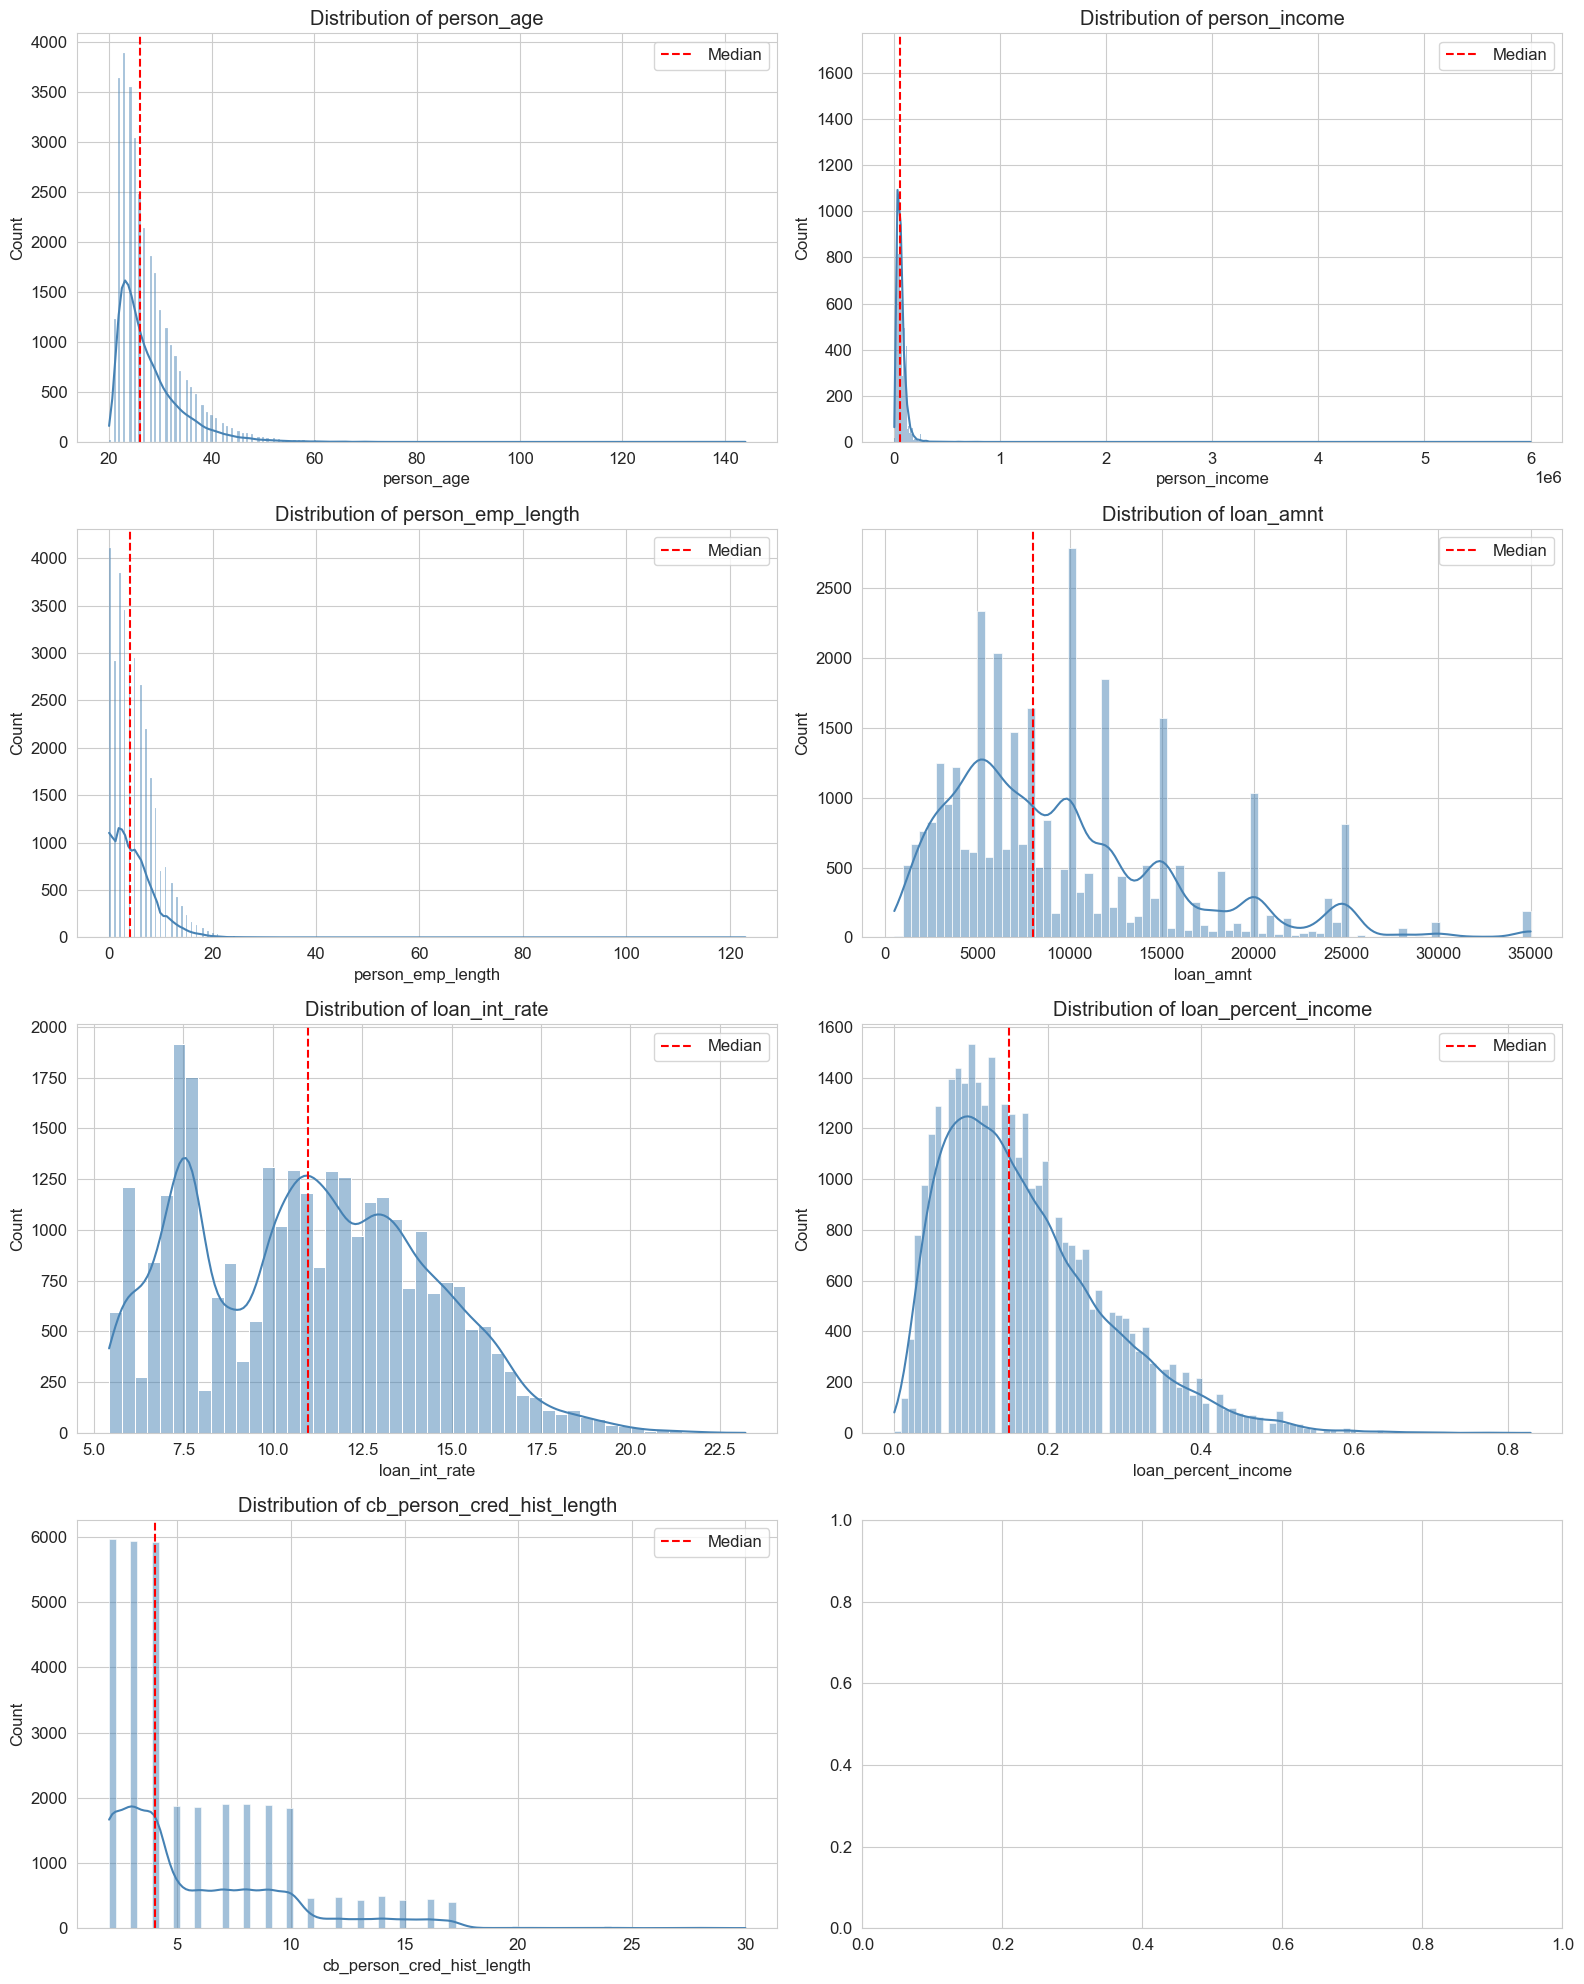

In [7]:
# Distribution Analisys - Numerical Feature
num_cols = ['person_age', 'person_income', 'person_emp_length', 
            'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].axvline(df[col].median(), color='red', linestyle='--', label='Median')
        axes[i].legend()

plt.tight_layout()
plt.show()

### Insight Distribusi:
- **person_age**: Sebagian besar peminjam berusia 20-40 tahun. Terdapat ekor kanan panjang.
- **person_income**: Sangat right-skewed. Mayoritas pendapatan di bawah 100rb.
- **loan_amnt**: Distribusi multimodal pada nilai-nilai tertentu (5k, 10k, 15k, 20k, 25k).
- **loan_int_rate**: Bimodal dengan puncak sekitar 7% dan 11%.
- **cb_person_cred_hist_length**: Rata-rata riwayat kredit 5 tahun.

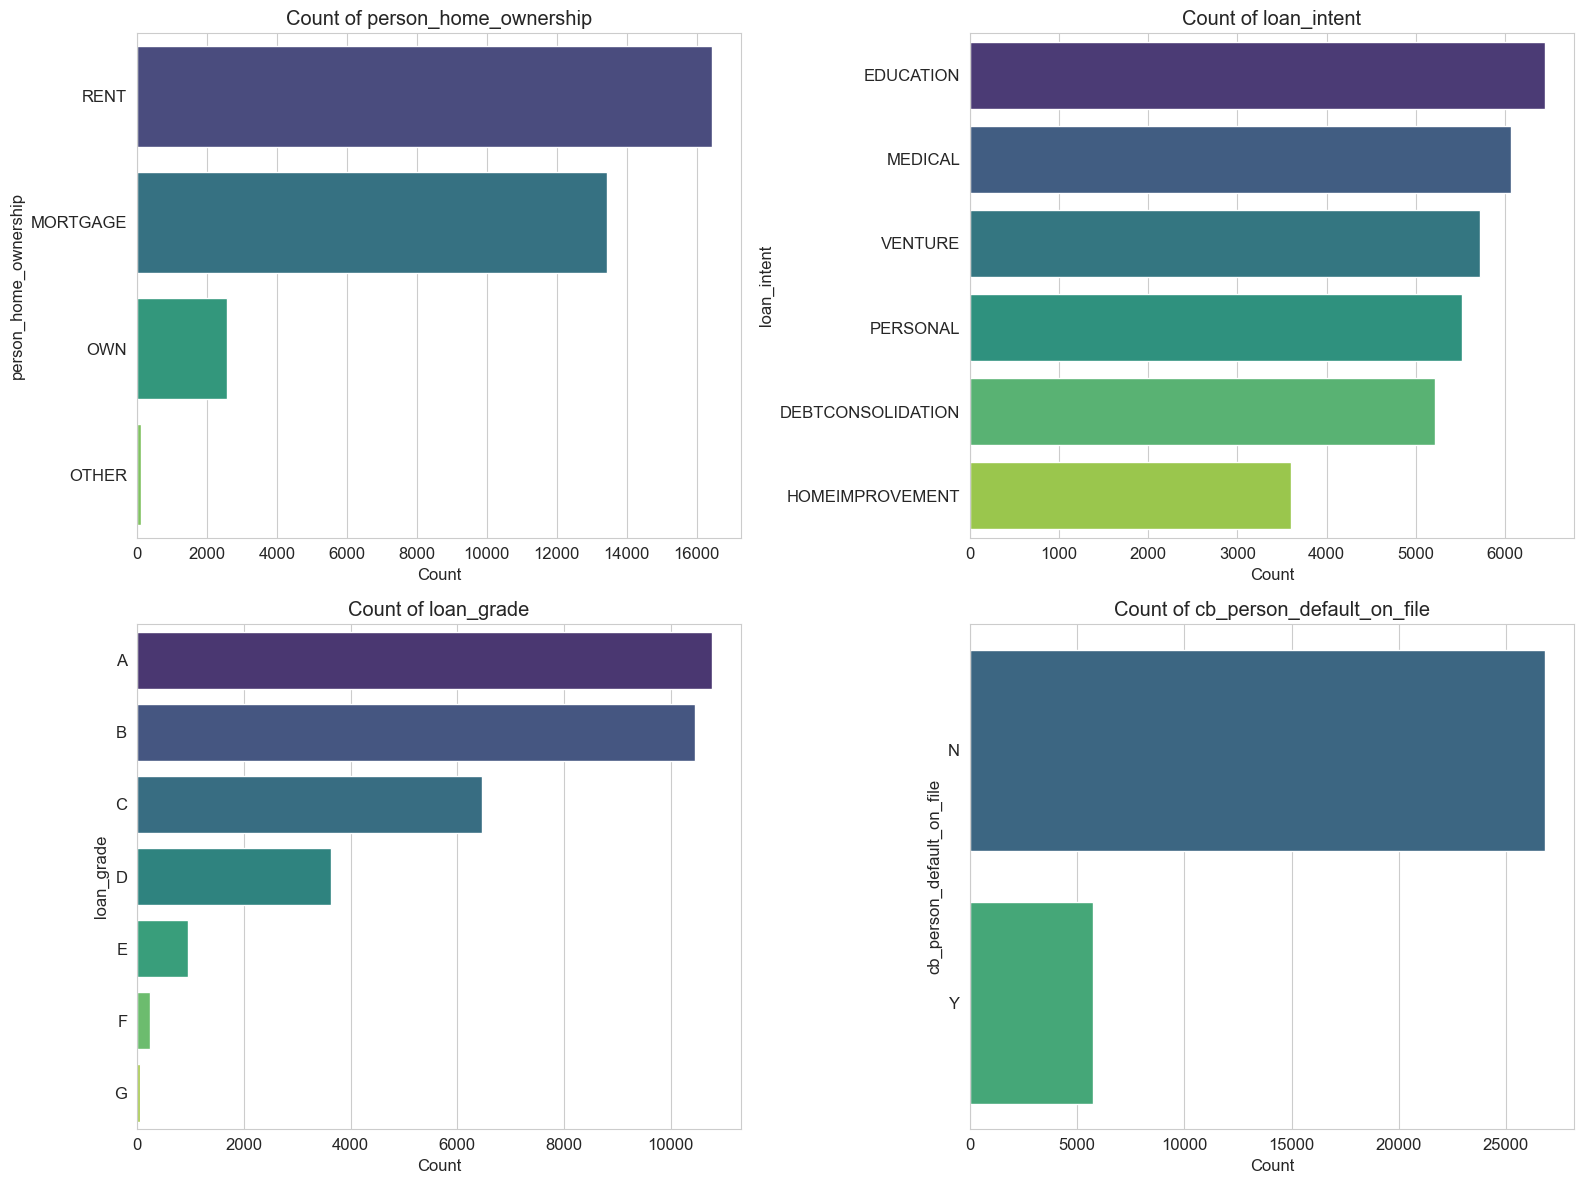

In [8]:
# Categorical Feature Distribution
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 
            'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='viridis')
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel('Count')

plt.tight_layout()
plt.show()

### Insight Kategorikal:
- **person_home_ownership**: Mayoritas `RENT` atau `MORTGAGE`.
- **loan_intent**: Terbanyak `EDUCATION`, `MEDICAL`, `VENTURE`.
- **loan_grade**: Grade A dan B paling banyak, C sedang, D, E, F, G semakin sedikit.
- **cb_person_default_on_file**: Sebagian besar `N` (tidak pernah default).

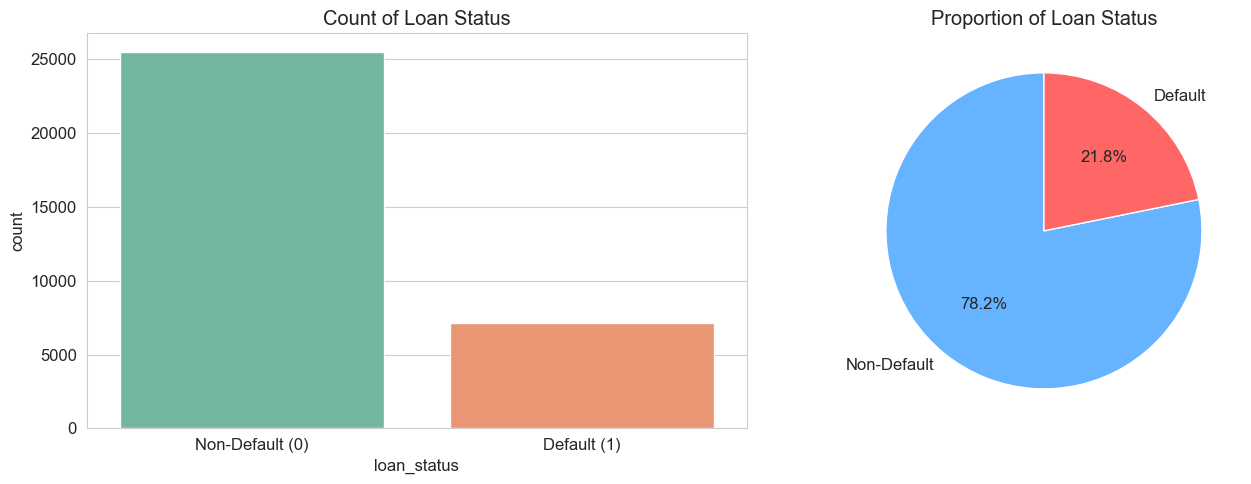

Imbalance Ratio (Default : Non-Default) = 1 : 3.6


In [9]:
# Target Variable Analisys
target_counts = df['loan_status'].value_counts()
target_pct = target_counts / len(df) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='loan_status', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Count of Loan Status')
ax[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])

ax[1].pie(target_counts, labels=['Non-Default', 'Default'], autopct='%1.1f%%', 
          colors=['#66b3ff','#ff6666'], startangle=90)
ax[1].set_title('Proportion of Loan Status')

plt.tight_layout()
plt.show()

print(f"Imbalance Ratio (Default : Non-Default) = 1 : {target_counts[0]/target_counts[1]:.1f}")

### Imbalance Analysis:
- Dataset **imbalanced**: 78.2% non-default, 21.8% default.
- Rasio ~ 3.5 : 1. 
- **Dampak**: Model dapat bias ke kelas mayoritas. Perlu teknik seperti class_weight atau resampling saat modeling.

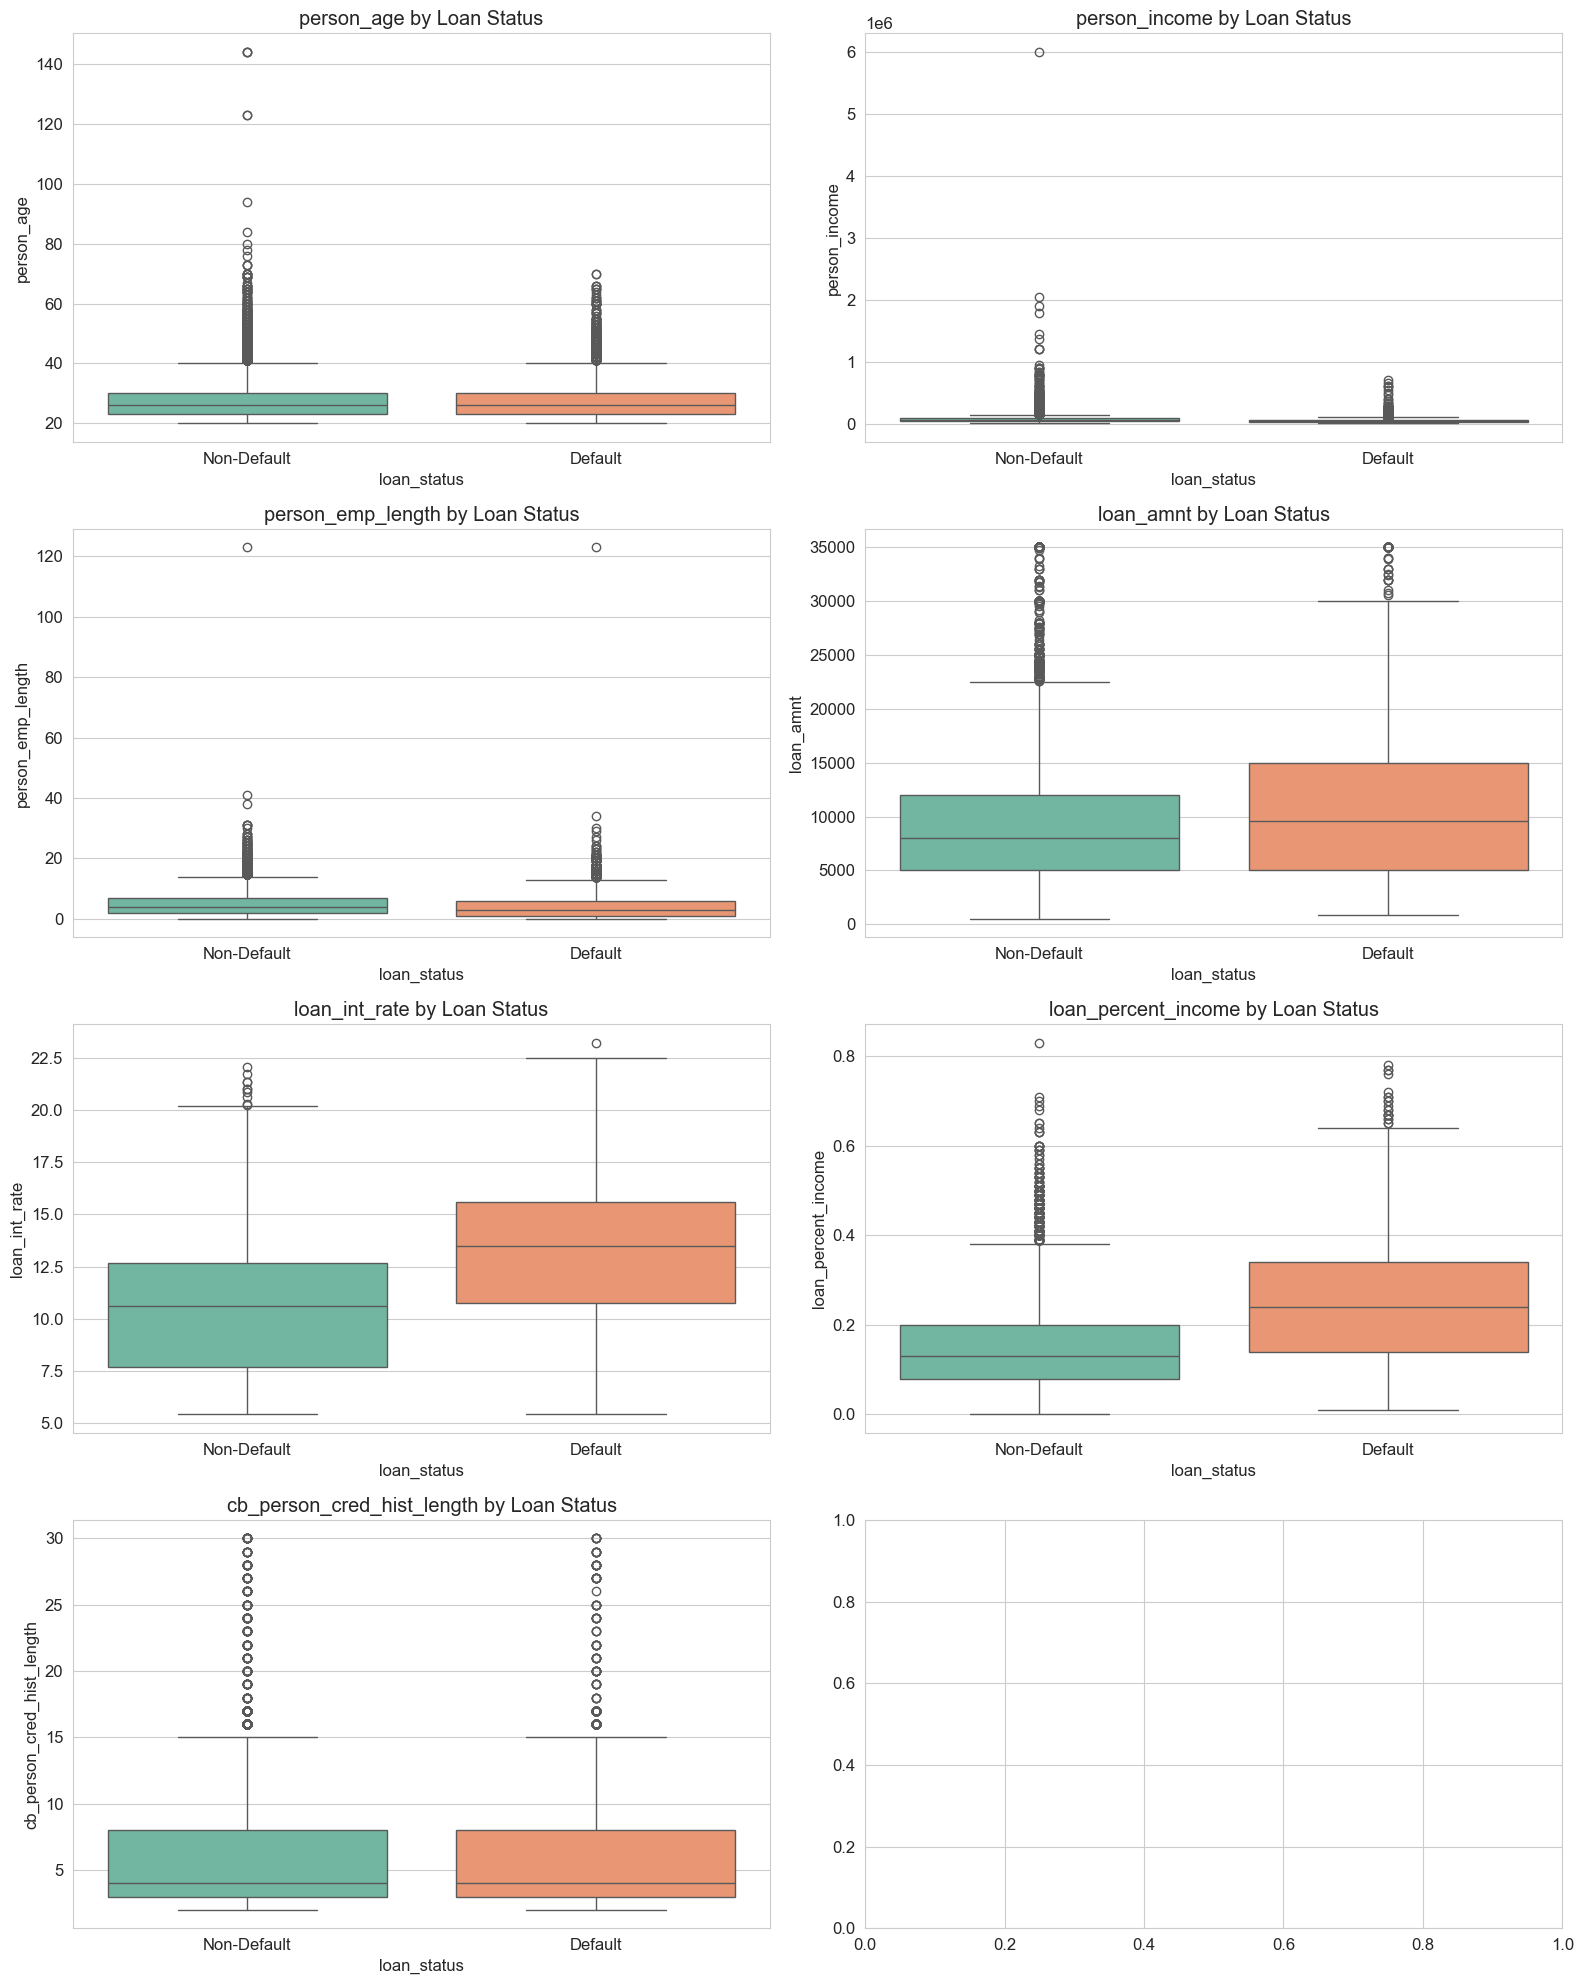

In [10]:
# Bivariate Analisys - Numerical vs Target
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        sns.boxplot(data=df, x='loan_status', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} by Loan Status')
        axes[i].set_xticklabels(['Non-Default', 'Default'])

plt.tight_layout()
plt.show()

### Insight Bivariate Numerik:
- **person_income**: Median pendapatan peminjam default lebih rendah.
- **loan_int_rate**: Default memiliki suku bunga median lebih tinggi (≈13% vs ≈10%).
- **loan_amnt**: Tidak ada perbedaan signifikan.
- **person_emp_length**: Default cenderung memiliki masa kerja lebih pendek.

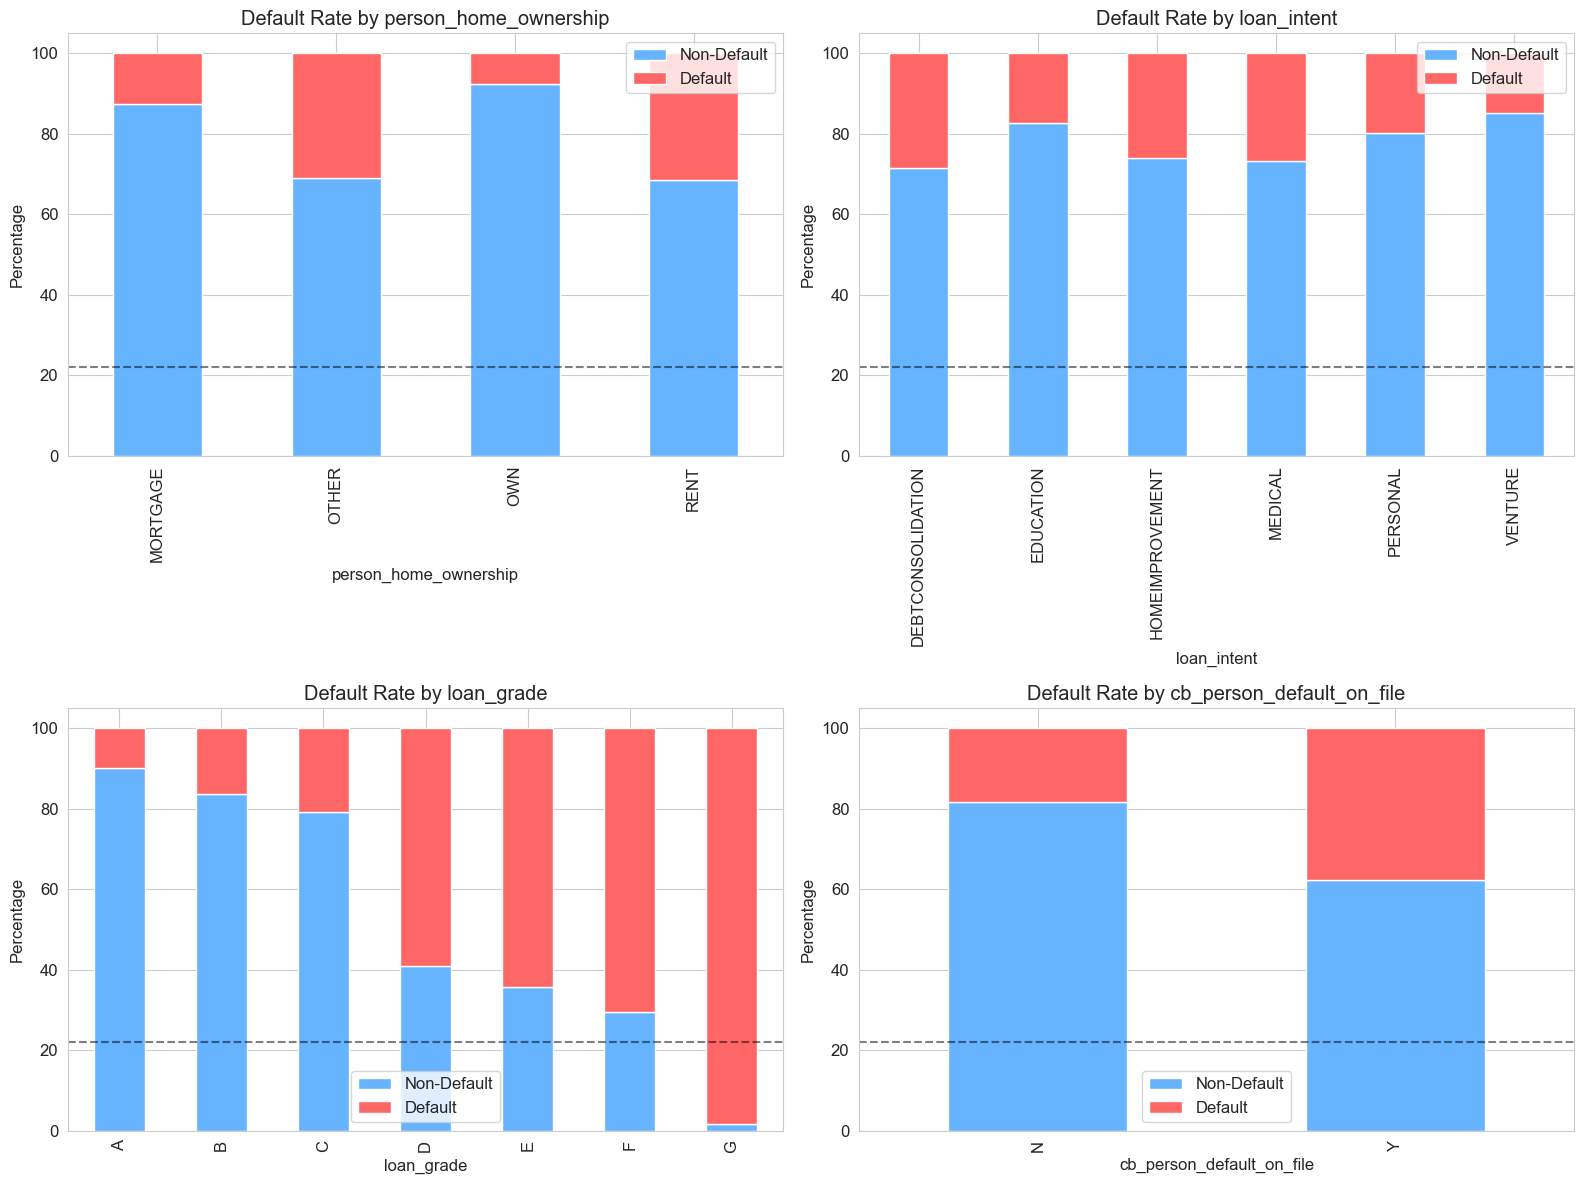

In [11]:
# Categorical vs Target
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff','#ff6666'])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['Non-Default', 'Default'])
    axes[i].axhline(y=22, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Insight Default Rate per Kategori:
- **loan_grade**: Grade D, E, F memiliki default rate jauh di atas rata-rata (22%).
- **cb_person_default_on_file**: Peminjam dengan riwayat default memiliki default rate > 50%.
- **person_home_ownership**: Status `RENT` memiliki default rate sedikit lebih tinggi.
- **loan_intent**: `DEBTCONSOLIDATION` cenderung lebih berisiko karena yang paling rendah.

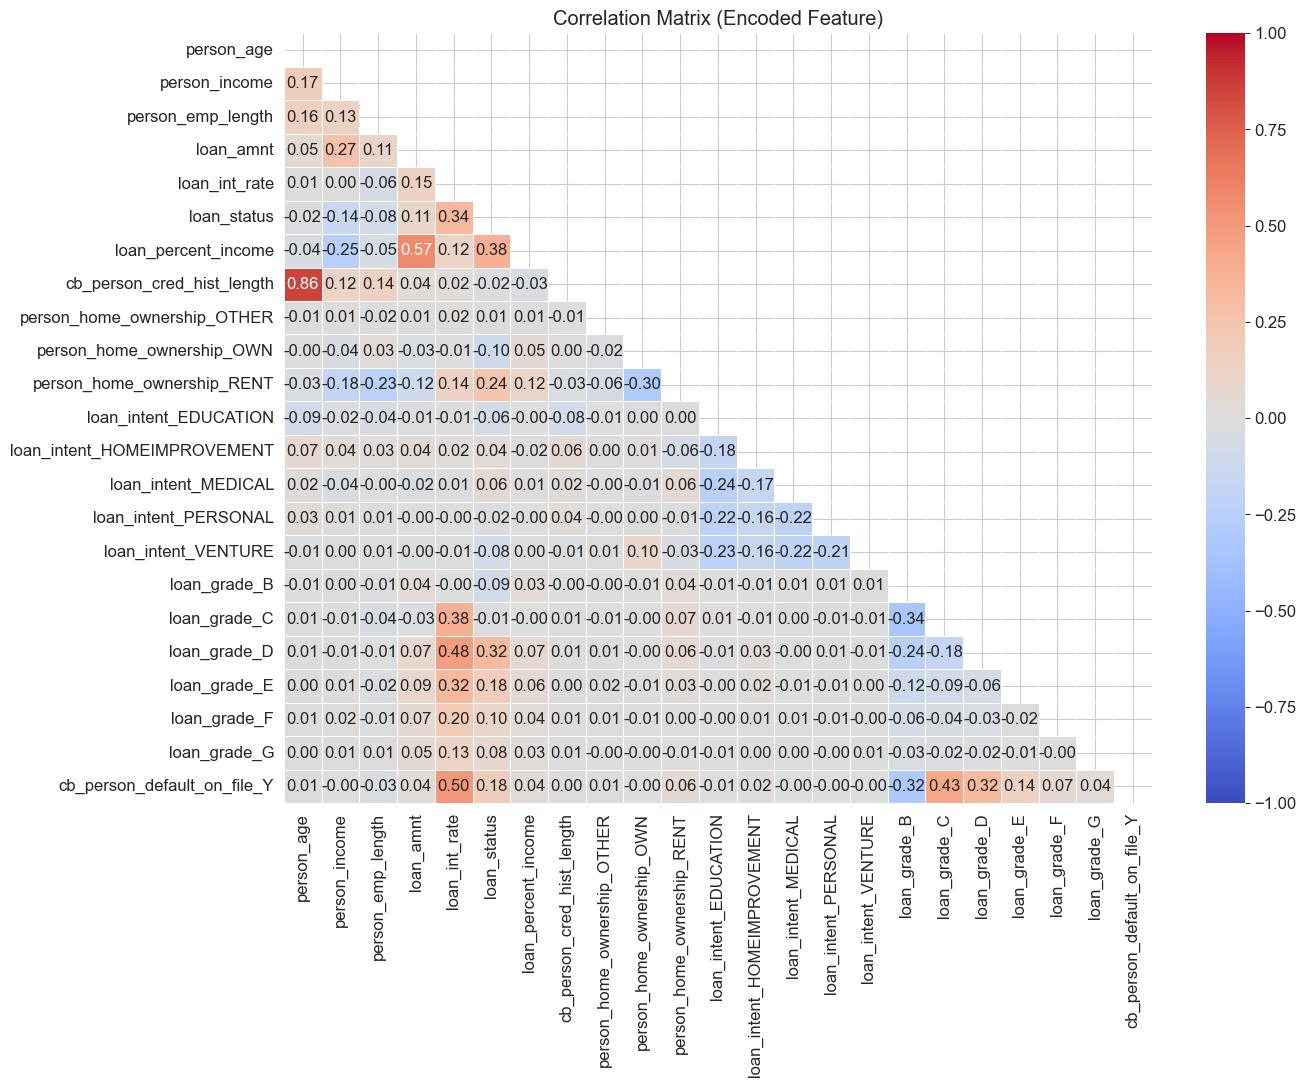

Top correlation with loan_status:
loan_percent_income            0.379366
loan_int_rate                  0.335133
loan_grade_D                   0.318998
person_home_ownership_RENT     0.238430
loan_grade_E                   0.180122
cb_person_default_on_file_Y    0.179141
loan_amnt                      0.105376
loan_grade_F                   0.101841
loan_grade_G                   0.082306
loan_intent_MEDICAL            0.056595
Name: loan_status, dtype: float64


In [12]:
# Correlation Analisys
# Encode categorical for correlation
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Encoded Feature)')
plt.show()

# Top correlation with target
corr_target = corr['loan_status'].drop('loan_status').sort_values(ascending=False)
print("Top correlation with loan_status:")
print(corr_target.head(10))

### Insight Korelasi

* **Prediktor Utama:** `loan_percent_income` dan `loan_int_rate` merupakan dua fitur dengan korelasi positif tertinggi terhadap status gagal bayar (*default*). Ini menunjukkan bahwa semakin besar persentase pinjaman terhadap pendapatan dan semakin tinggi suku bunga, semakin besar pula risiko gagal bayar.
* **Pengaruh Peringkat Pinjaman:** Kategori pinjaman dengan tingkat risiko menengah hingga tinggi yang telah di-*encode* (seperti `loan_grade_D`, `E`, `F`, dan `G`) menunjukkan korelasi positif yang signifikan terhadap risiko *default*.
* **Status Kepemilikan Rumah:** Status penyewa rumah (`person_home_ownership_RENT`) memiliki korelasi positif sebesar **0.238**, yang mengindikasikan bahwa nasabah yang menyewa rumah cenderung memiliki risiko *default* yang lebih tinggi dibandingkan kategori kepemilikan lainnya.
* **Riwayat Kredit:** Adanya riwayat gagal bayar sebelumnya (`cb_person_default_on_file_Y`) memiliki korelasi positif lemah sebesar **0.179** terhadap status *default* saat ini.

In [13]:
# Outlier Detection (IQR Method)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

outlier_summary = []
for col in num_cols:
    count, low, high = detect_outliers_iqr(df, col)
    outlier_summary.append([col, count, count/len(df)*100, low, high])

outlier_df = pd.DataFrame(outlier_summary, columns=['Feature', 'Outlier Count', 'Percentage', 'Lower Bound', 'Upper Bound'])
outlier_df.sort_values('Percentage', ascending=False)

,Feature,Outlier Count,Percentage,Lower Bound,Upper Bound
3,loan_amnt,1689,5.184003,-5800.000,23000.000
0,person_age,1494,4.585495,12.500,40.500
1,person_income,1484,4.554802,-22550.000,140250.000
6,cb_person_cred_hist_length,1142,3.505110,-4.500,15.500
2,person_emp_length,853,2.618090,-5.500,14.500
5,loan_percent_income,651,1.998097,-0.120,0.440
4,loan_int_rate,6,0.018416,-0.455,21.825


### Outlier Summary:
- **person_age**: > 40.5 dianggap outlier (≈4.58%).
- **person_emp_length**: > 14.5 dianggap outlier (≈2.61%).
- **person_income**: > 140.250 dianggap outlier (≈4.55%).
- **loan_percent_income**: > 0.44 dianggap outlier (≈1.99%).
- **Strategi**: Untuk modeling, outlier akan di-cap pada batas atas/bawah (winsorizing) daripada dihapus karena data terbatas.

In [14]:
default_rate = df['loan_status'].mean() * 100

print("=== CREDIT RISK BUSINESS INSIGHTS ===\n")

print(f"1. Tingkat Gagal Bayar (Default Rate): {default_rate:.1f}%")

print("\n2. Faktor Risiko Utama (Berdasarkan Korelasi):")
print("   - Rasio Pinjaman terhadap Pendapatan (loan_percent_income): prediktor TERKUAT (~0.38)")
print("   - Suku Bunga Pinjaman (loan_int_rate): indikator risiko kuat (~0.33)")
print("   - Grade Pinjaman D/E/F/G: kemungkinan gagal bayar lebih tinggi")
print("   - Status tempat tinggal RENT (sewa): lebih berisiko dibanding OWN (milik sendiri)")
print("   - Riwayat gagal bayar sebelumnya: sinyal risiko signifikan")

print("\n3. Interpretasi Risiko:")
print("   - Peminjam dengan rasio pinjaman terhadap pendapatan tinggi (>0.44) cenderung over-leverage")
print("   - Suku bunga tinggi mencerminkan penilaian risiko oleh pemberi pinjaman")
print("   - Grade kredit rendah (D-G) menunjukkan kelayakan kredit yang lemah")
print("   - Penyewa (rent) cenderung memiliki stabilitas finansial lebih rendah dibanding pemilik rumah")

print("\n4. Insight Kualitas Data / Outlier:")
print("   - loan_amnt & income memiliki ~5% outlier → berpotensi menyebabkan bias")
print("   - Batas atas usia (~40.5) mengindikasikan kemungkinan adanya pembatasan data (capping)")
print("   - loan_percent_income dibatasi sekitar 0.44 → sesuai dengan threshold risiko")

print("\n5. Strategi yang Direkomendasikan:")

print("   - Aturan Ketatnya Tolak atau tandai aplikasi dengan loan_percent_income > 0.44")
print("   - Tingkatkan pengawasan untuk pinjaman dengan suku bunga di atas median dataset")
print("   - Perketat persetujuan untuk Grade D ke bawah (berbasis data, bukan asumsi)")
print("   - Terapkan pengecekan lebih ketat untuk peminjam dengan riwayat gagal bayar")
print("   - Prioritaskan segmen risiko rendah: Grade A-B, pemilik rumah, rasio utang rendah")

print("\n6. Penyelarasan dengan Strategi Bisnis:")
print("   - Fokus pada kemampuan bayar (Debt-to-Income) sebagai variabel utama")
print("   - Hindari hanya mengandalkan loan grade (berpotensi menyebabkan data leakage)")
print("   - Kombinasikan beberapa indikator risiko, bukan hanya satu threshold")

=== CREDIT RISK BUSINESS INSIGHTS ===

1. Tingkat Gagal Bayar (Default Rate): 21.8%

2. Faktor Risiko Utama (Berdasarkan Korelasi):
   - Rasio Pinjaman terhadap Pendapatan (loan_percent_income): prediktor TERKUAT (~0.38)
   - Suku Bunga Pinjaman (loan_int_rate): indikator risiko kuat (~0.33)
   - Grade Pinjaman D/E/F/G: kemungkinan gagal bayar lebih tinggi
   - Status tempat tinggal RENT (sewa): lebih berisiko dibanding OWN (milik sendiri)
   - Riwayat gagal bayar sebelumnya: sinyal risiko signifikan

3. Interpretasi Risiko:
   - Peminjam dengan rasio pinjaman terhadap pendapatan tinggi (>0.44) cenderung over-leverage
   - Suku bunga tinggi mencerminkan penilaian risiko oleh pemberi pinjaman
   - Grade kredit rendah (D-G) menunjukkan kelayakan kredit yang lemah
   - Penyewa (rent) cenderung memiliki stabilitas finansial lebih rendah dibanding pemilik rumah

4. Insight Kualitas Data / Outlier:
   - loan_amnt & income memiliki ~5% outlier → berpotensi menyebabkan bias
   - Batas atas usi

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### Train Test Split

In [15]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (26064, 11)
X_test shape:  (6517, 11)


### Handle Missing Values & Outlier

In [16]:
train_medians = X_train.groupby('loan_grade')['loan_int_rate'].median()
overall_median = X_train['loan_int_rate'].median()

# Impute ke X_train
X_train['loan_int_rate'] = X_train.apply(
    lambda row: train_medians.get(row['loan_grade'], overall_median) if pd.isna(row['loan_int_rate']) else row['loan_int_rate'],
    axis=1
)

# Impute ke X_test
X_test['loan_int_rate'] = X_test.apply(
    lambda row: train_medians.get(row['loan_grade'], overall_median) if pd.isna(row['loan_int_rate']) else row['loan_int_rate'],
    axis=1
)

# Impute person_emp_length
emp_median = X_train['person_emp_length'].median()
X_train['person_emp_length'] = X_train['person_emp_length'].fillna(emp_median)
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(emp_median)

### Outlier Treatment

In [ ]:
X_train['person_age'] = X_train['person_age'].clip(upper=65)
X_test['person_age'] = X_test['person_age'].clip(upper=65)

X_train['person_emp_length'] = X_train['person_emp_length'].clip(upper=40)
X_test['person_emp_length'] = X_test['person_emp_length'].clip(upper=40)

X_train['loan_percent_income'] = X_train['loan_percent_income'].clip(upper=0.6)
X_test['loan_percent_income'] = X_test['loan_percent_income'].clip(upper=0.6)

X_train['person_income'] = np.log1p(X_train['person_income'])
X_test['person_income'] = np.log1p(X_test['person_income'])

income_cap = X_train['person_income'].quantile(0.99) # Dihitung dari train
X_train['person_income'] = X_train['person_income'].clip(upper=income_cap)
X_test['person_income'] = X_test['person_income'].clip(upper=income_cap)

### Encoding Kategorikal

In [18]:
# Ordinal Encoding
oe = OrdinalEncoder(categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']])
X_train['loan_grade'] = oe.fit_transform(X_train[['loan_grade']])
X_test['loan_grade'] = oe.transform(X_test[['loan_grade']])

# One Hot Encoding
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")

train_encoded = ohe.fit_transform(X_train[cat_cols])
test_encoded = ohe.transform(X_test[cat_cols])

X_train = pd.concat([X_train.drop(columns=cat_cols), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), test_encoded], axis=1)

### Normalisasi Fitur Numerik

In [19]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols]) # Hanya transform pada test

### Save Dataset Preprocessing

In [20]:
os.makedirs('credit_risk_preprocessing', exist_ok=True)

X_train.to_csv('credit_risk_preprocessing/X_train.csv', index=False)
X_test.to_csv('credit_risk_preprocessing/X_test.csv',   index=False)
y_train.to_csv('credit_risk_preprocessing/y_train.csv', index=False)
y_test.to_csv('credit_risk_preprocessing/y_test.csv',   index=False)

print("Dataset preprocessing successfuly saved!")

Dataset preprocessing successfuly saved!
